# 单孔漏斗爆破：多通道动态 STVMD 分析

本 Notebook 以仓库算法及其对应论文为主，按步长1对三个方向分别分析。

## 1. 参数配置

In [33]:
from dataclasses import dataclass
from pathlib import Path
import json
import os
import re
import warnings

import numpy as np
import pandas as pd
import scipy.fft
import scipy.signal
import matplotlib.pyplot as plt
from IPython.display import display

In [35]:
K = 6
ALPHA = 200.0

# STVMD时窗长度，单位为采样点
WINDOW_LENGTH = 1024

TAU = 1e-5
TOL = 1e-5
MAX_ITERS = 300

# 每批计算多少个滑动窗口
BATCH_WINDOWS = 128

PLOT_MAX_HZ = 200.0
SAVE_OUTPUTS = True

print(
    f"K={K}, alpha={ALPHA}, window={WINDOW_LENGTH}, "
    f"batch={BATCH_WINDOWS}, max_iters={MAX_ITERS}"
)

K=6, alpha=200.0, window=1024, batch=128, max_iters=300


## 2. 数据读取与校验

In [25]:
@dataclass(frozen=True)
class BlastRecord:
    path: Path
    metadata: dict
    fs: float
    pretrigger_seconds: float
    columns: tuple
    data: np.ndarray


def _metadata_number(metadata, key):
    if key not in metadata:
        raise ValueError(f"缺少元数据字段: {key}")
    match = re.search(r"[-+]?\d+(?:\.\d+)?", metadata[key])
    if match is None:
        raise ValueError(f"无法解析元数据字段 {key}: {metadata[key]!r}")
    return float(match.group())


def load_instantel_txt(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"找不到输入文件: {path}")
    lines = path.read_text(encoding="utf-8-sig", errors="replace").splitlines()
    metadata = {}
    header_index = None
    for index, raw in enumerate(lines):
        stripped = raw.strip().strip('"')
        if all(name in stripped for name in ("Tran", "Vert", "Long")):
            header_index = index
            break
        if ":" in stripped:
            key, value = stripped.split(":", 1)
            metadata[key.strip()] = value.strip()
    if header_index is None:
        raise ValueError(f"{path.name}: 未找到 Tran/Vert/Long 数据表头")
    data = np.loadtxt(lines[header_index + 1 :], dtype=float)
    data = np.atleast_2d(data)
    if data.shape[1] != 3:
        raise ValueError(f"{path.name}: 期望3列数据，实际为{data.shape[1]}列")
    if not np.isfinite(data).all():
        raise ValueError(f"{path.name}: 数据包含 NaN 或无穷值")
    fs = _metadata_number(metadata, "Sample Rate")
    pretrigger = abs(_metadata_number(metadata, "Pre-trigger Length"))
    if fs <= 0:
        raise ValueError(f"{path.name}: 采样率必须为正数")
    return BlastRecord(
        path=path,
        metadata=metadata,
        fs=fs,
        pretrigger_seconds=pretrigger,
        columns=("Tran", "Vert", "Long"),
        data=data,
    )


def convert_instantel_ascii_to_csv(txt_path, csv_path):
    txt_path, csv_path = Path(txt_path), Path(csv_path)
    if not txt_path.is_file():
        raise FileNotFoundError(f"找不到输入文件: {txt_path}")
    lines = txt_path.read_text(
        encoding="utf-8-sig", errors="replace"
    ).splitlines()
    metadata, header_index = {}, None
    for index, raw in enumerate(lines):
        stripped = raw.strip().strip('"')
        if all(name in stripped for name in ("Tran", "Vert", "Long")):
            header_index = index
            break
        if ":" in stripped:
            key, value = stripped.split(":", 1)
            metadata[key.strip()] = value.strip()
    if header_index is None:
        raise ValueError(f"{txt_path.name}: 未找到 Tran/Vert/Long 表头")
    fs = _metadata_number(metadata, "Sample Rate")
    pretrigger = abs(_metadata_number(metadata, "Pre-trigger Length"))
    frame = pd.read_csv(
        txt_path,
        sep=r"\s+",
        skiprows=header_index + 1,
        names=["Tran", "Vert", "Long"],
        engine="python",
    )
    if frame.shape[1] != 3 or frame.isna().any().any():
        raise ValueError(f"{txt_path.name}: 数值区不是有效的三列数据")
    frame.insert(
        0, "Time_s", np.arange(len(frame)) / fs - pretrigger
    )
    frame.insert(0, "Sample", np.arange(len(frame), dtype=int))
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(csv_path, index=False)
    return {
        "fs": fs,
        "pretrigger_seconds": pretrigger,
        "metadata": metadata,
    }


def prepare_direction_inputs(records):
    order = ("5m", "10m", "15m")
    missing = [key for key in order if key not in records]
    if missing:
        raise ValueError(f"缺少测点记录: {missing}")
    fs_values = np.array([records[key].fs for key in order], dtype=float)
    pre_values = np.array(
        [records[key].pretrigger_seconds for key in order], dtype=float
    )
    if not np.allclose(fs_values, fs_values[0]):
        raise ValueError(f"采样率不一致: {fs_values.tolist()}")
    if not np.allclose(pre_values, pre_values[0]):
        raise ValueError(f"预触发长度不一致: {pre_values.tolist()}")
    common_n = min(records[key].data.shape[0] for key in order)
    signals = {}
    for column_index, direction in enumerate(("Tran", "Vert", "Long")):
        signals[direction] = np.vstack(
            [records[key].data[:common_n, column_index] for key in order]
        )
    time_s = np.arange(common_n) / fs_values[0] - pre_values[0]
    return signals, time_s

In [26]:
DATA_FILES = {"5m": Path("5m.TXT"), "10m": Path("10m.TXT"), "15m": Path("15m.TXT")}
records = {
    distance: load_instantel_txt(path)
    for distance, path in DATA_FILES.items()
}
signals, time_s = prepare_direction_inputs(records)
fs = records["5m"].fs
if QUICK_TEST:
    trigger_index = int(round(records["5m"].pretrigger_seconds * fs))
    quick_start = max(0, trigger_index - 128)
    quick_stop = min(time_s.size, quick_start + 512)
    signals = {
        key: value[:, quick_start:quick_stop] for key, value in signals.items()
    }
    time_s = time_s[quick_start:quick_stop]

print("采样率:", fs, "Hz")
print("共同样本数:", time_s.size)
print("时间范围:", (float(time_s[0]), float(time_s[-1])), "s")
print("频率分辨率:", fs / WINDOW_LENGTH, "Hz")
for distance, record in records.items():
    print(distance, record.data.shape, record.metadata.get("Event Time", ""))

采样率: 4096.0 Hz
共同样本数: 14336
时间范围: (-0.5, 2.999755859375) s
频率分辨率: 4.0 Hz
5m (33493, 3) 15:41:05
10m (14336, 3) 15:41:18
15m (23176, 3) 15:40:50


## 3. 动态多通道 STVMD

In [37]:
REPOSITORY_WINDOWS = (8, 16, 32, 64, 128, 256, 512, 1024)


def validate_config(K, alpha, window_length, batch_windows, max_iters):
    if K not in (3, 4, 5, 6):
        raise ValueError("K 必须为 3、4 或 5")
    if not np.isfinite(alpha) or alpha <= 0:
        raise ValueError("ALPHA 必须为有限正数")
    if window_length not in REPOSITORY_WINDOWS:
        raise ValueError(f"WINDOW_LENGTH 必须来自 {REPOSITORY_WINDOWS}")
    if batch_windows < 1:
        raise ValueError("BATCH_WINDOWS 必须大于0")
    if max_iters < 2:
        raise ValueError("MAX_ITERS 必须至少为2")


def _pad_width(window_length):
    left = window_length // 2
    return left, window_length - 1 - left


def _window_batch(x_padded, window_length, start, stop, window):
    views = np.lib.stride_tricks.sliding_window_view(
        x_padded, window_shape=window_length, axis=1
    )
    segments = np.moveaxis(views[:, start:stop, :], 1, 2)
    return segments * window[None, :, None]


def _solve_dynamic_batch(f_hat, K, alpha, tau, tol, max_iters):
    channels, freq_bins, batch_n = f_hat.shape
    normalized_freq = np.arange(1, freq_bins + 1, dtype=float) / freq_bins
    u = np.zeros(
        (2, channels, freq_bins, K, batch_n), dtype=np.complex128
    )
    lagrange = np.zeros(
        (2, channels, freq_bins, batch_n), dtype=np.complex128
    )
    omega = np.zeros((2, K, batch_n), dtype=float)
    for mode in range(K):
        omega[0, mode, :] = mode / K

    active = np.ones(batch_n, dtype=bool)
    converged_windows = np.zeros(batch_n, dtype=bool)
    last_window_diff = np.full(batch_n, np.inf)
    final_diff = np.inf
    for iteration in range(max_iters):
        current = iteration % 2
        updated = (iteration + 1) % 2
        u[updated].fill(0)
        omega[updated] = omega[current]
        running_sum = np.sum(u[current], axis=2)
        for mode in range(K):
            running_sum -= u[current, :, :, mode, :]
            denominator = 1.0 + alpha * (
                normalized_freq[:, None] - omega[current, mode, :][None, :]
            ) ** 2
            u[updated, :, :, mode, :] = (
                f_hat - running_sum - lagrange[current] / 2.0
            ) / denominator[None, :, :]
            running_sum += u[updated, :, :, mode, :]
            if mode == 0:
                omega[updated, mode, :] = 0.0
            else:
                mode_power = np.sum(
                    np.abs(u[updated, :, :, mode, :]) ** 2, axis=0
                )
                denominator_power = np.sum(mode_power, axis=0)
                numerator_power = np.sum(
                    normalized_freq[:, None] * mode_power, axis=0
                )
                omega[updated, mode, :] = np.divide(
                    numerator_power,
                    denominator_power,
                    out=np.zeros_like(numerator_power),
                    where=denominator_power > np.finfo(float).eps,
                )
        lagrange[updated] = lagrange[current] + tau * (
            np.sum(u[updated], axis=2) - f_hat
        )
        inactive_columns = np.flatnonzero(~active)
        if inactive_columns.size:
            u[updated, :, :, :, inactive_columns] = u[
                current, :, :, :, inactive_columns
            ]
            omega[updated, :, inactive_columns] = omega[
                current, :, inactive_columns
            ]
            lagrange[updated, :, :, inactive_columns] = lagrange[
                current, :, :, inactive_columns
            ]
        window_diff = np.max(
            np.mean(np.abs(u[updated] - u[current]) ** 2, axis=(1, 2)),
            axis=0,
        )
        last_window_diff[active] = window_diff[active]
        if iteration >= 2:
            newly_converged = active & (window_diff < tol)
            converged_windows[newly_converged] = True
            active[newly_converged] = False
            if not np.any(active):
                break

    final_index = (iteration + 1) % 2
    u_final = u[final_index].copy()
    omega_final = omega[final_index].copy()
    for column in range(batch_n):
        order = np.argsort(omega_final[:, column])
        u_final[:, :, :, column] = (
            u_final[:, :, :, column][:, :, order].copy()
        )
        omega_final[:, column] = omega_final[order, column]
    final_diff = float(np.max(last_window_diff))
    return (
        u_final,
        omega_final,
        iteration + 1,
        bool(np.all(converged_windows)),
        final_diff,
    )


def run_dynamic_stvmd_batched(
    x,
    fs,
    K=4,
    alpha=50.0,
    window_length=64,
    tau=1e-5,
    tol=1e-9,
    max_iters=2000,
    batch_windows=256,
):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError("输入必须为 (通道, 时间) 二维数组")
    if not np.isfinite(x).all():
        raise ValueError("输入包含 NaN 或无穷值")
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError("采样率必须为有限正数")
    validate_config(K, alpha, window_length, batch_windows, max_iters)
    channels, sample_n = x.shape
    if sample_n < window_length:
        raise ValueError("样本数不能小于 WINDOW_LENGTH")

    left, right = _pad_width(window_length)
    x_padded = np.pad(x, ((0, 0), (left, right)), mode="reflect")
    window = scipy.signal.windows.hamming(window_length, sym=False)
    freq_bins = window_length // 2 + 1
    modes_accum = np.zeros(
        (K, channels, sample_n + window_length - 1), dtype=float
    )
    norm = np.zeros(sample_n + window_length - 1, dtype=float)
    center_freq_hz = np.zeros((K, sample_n), dtype=float)
    mean_tf_power = np.zeros((freq_bins, sample_n), dtype=float)
    iterations = []
    convergence = []

    for start in range(0, sample_n, batch_windows):
        stop = min(sample_n, start + batch_windows)
        windowed = _window_batch(
            x_padded, window_length, start, stop, window
        )
        f_hat = scipy.fft.rfft(windowed, axis=1, workers=-1)
        mean_tf_power[:, start:stop] = np.mean(np.abs(f_hat) ** 2, axis=0)
        u_hat, omega, count, converged, diff = _solve_dynamic_batch(
            f_hat, K, alpha, tau, tol, max_iters
        )
        center_freq_hz[:, start:stop] = omega * (fs / 2.0)
        batch_modes = scipy.fft.irfft(
            u_hat, n=window_length, axis=1, workers=-1
        ).real
        for local_column, global_column in enumerate(range(start, stop)):
            target = slice(global_column, global_column + window_length)
            norm[target] += window ** 2
            for mode in range(K):
                modes_accum[mode, :, target] += (
                    batch_modes[:, :, mode, local_column] * window[None, :]
                )
        iterations.append(count)
        convergence.append((converged, diff))

    safe_norm = np.where(norm > np.finfo(float).eps, norm, 1.0)
    modes_full = modes_accum / safe_norm[None, None, :]
    modes = modes_full[:, :, left : left + sample_n]
    return {
        "modes": modes,
        "center_freq_hz": center_freq_hz,
        "mean_tf_power": mean_tf_power,
        "iterations": np.asarray(iterations, dtype=int),
        "converged": np.asarray([item[0] for item in convergence], dtype=bool),
        "final_diff": np.asarray(
            [item[1] for item in convergence], dtype=float
        ),
    }

In [28]:
def power_to_db(power, floor_db=-100.0):
    power = np.asarray(power, dtype=float)
    peak = float(np.max(power))
    if not np.isfinite(peak) or peak <= 0:
        return np.full_like(power, floor_db)
    db = 10.0 * np.log10(
        np.maximum(power / peak, 10 ** (floor_db / 10))
    )
    return np.maximum(db, floor_db)


def _energy_band(freq_hz, power, low=0.05, high=0.95):
    power = np.maximum(np.asarray(power, dtype=float), 0.0)
    total = float(np.sum(power))
    if total <= np.finfo(float).eps:
        return np.array([0.0, 0.0])
    cumulative = np.cumsum(power) / total
    return np.array(
        [
            np.interp(low, cumulative, freq_hz),
            np.interp(high, cumulative, freq_hz),
        ]
    )


def summarize_stvmd_result(x, fs, raw_result):
    modes = raw_result["modes"]
    reconstruction = np.sum(modes, axis=0)
    denominator = np.linalg.norm(x, axis=1)
    nrmse = np.divide(
        np.linalg.norm(x - reconstruction, axis=1),
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > np.finfo(float).eps,
    )
    mode_energy = np.sum(modes ** 2, axis=2)
    channel_energy = np.sum(mode_energy, axis=0, keepdims=True)
    energy_fraction = np.divide(
        mode_energy,
        channel_energy,
        out=np.zeros_like(mode_energy),
        where=channel_energy > np.finfo(float).eps,
    )
    freq_hz = scipy.fft.rfftfreq(modes.shape[-1], d=1.0 / fs)
    bands = np.zeros((modes.shape[0], 2), dtype=float)
    mode_power = np.zeros((modes.shape[0], freq_hz.size), dtype=float)
    for mode in range(modes.shape[0]):
        spectra = scipy.fft.rfft(modes[mode], axis=1, workers=-1)
        mode_power[mode] = np.sum(np.abs(spectra) ** 2, axis=0)
        bands[mode] = _energy_band(freq_hz, mode_power[mode])
    result = dict(raw_result)
    result.update(
        {
            "reconstruction": reconstruction,
            "nrmse": nrmse,
            "energy_fraction": energy_fraction,
            "frequency_hz": freq_hz,
            "mode_power": mode_power,
            "frequency_bands_hz": bands,
        }
    )
    return result

In [29]:
DISTANCE_LABELS = ("5 m", "10 m", "15 m")
MODE_COLORS = ("#64748b", "#0072B2", "#D55E00", "#009E73", "#CC79A7")


def _frequency_extent(time_s, fs, frequency_bins):
    return [time_s[0], time_s[-1], 0.0, fs / 2.0]


def _limit_frequency_axis(axis, plot_max_hz, fs):
    axis.set_ylim(0.0, min(float(plot_max_hz), fs / 2.0))
    axis.set_ylabel("Frequency (Hz)")


def plot_input_and_tf(direction, x, time_s, fs, result, plot_max_hz):
    fig, axes = plt.subplots(
        1, 2, figsize=(12, 4.2), constrained_layout=True
    )
    for channel, label in enumerate(DISTANCE_LABELS):
        axes[0].plot(time_s, x[channel], lw=0.8, label=label)
    axes[0].axvline(0, color="black", ls="--", lw=0.8)
    axes[0].set(
        xlabel="Time (s)",
        ylabel="Velocity (mm/s)",
        title=f"{direction}: input velocity",
    )
    axes[0].legend(frameon=False)
    image = axes[1].imshow(
        power_to_db(result["mean_tf_power"]),
        origin="lower",
        aspect="auto",
        extent=_frequency_extent(
            time_s, fs, result["mean_tf_power"].shape[0]
        ),
        cmap="viridis",
        vmin=-80,
        vmax=0,
    )
    _limit_frequency_axis(axes[1], plot_max_hz, fs)
    axes[1].set(xlabel="Time (s)", title="Mean multichannel TF power")
    fig.colorbar(image, ax=axes[1], label="Relative power (dB)")
    return fig


def plot_modes(direction, time_s, result):
    modes = result["modes"]
    mode_n, channel_n, _ = modes.shape
    fig, axes = plt.subplots(
        mode_n,
        channel_n,
        figsize=(12, max(4.0, 2.1 * mode_n)),
        sharex=True,
        squeeze=False,
        constrained_layout=True,
    )
    for mode in range(mode_n):
        row_name = "Residual" if mode == 0 else f"Mode {mode}"
        for channel in range(channel_n):
            axis = axes[mode, channel]
            axis.plot(
                time_s,
                modes[mode, channel],
                color=MODE_COLORS[mode],
                lw=0.7,
            )
            axis.axvline(0, color="black", ls="--", lw=0.6)
            if mode == 0:
                axis.set_title(DISTANCE_LABELS[channel])
            if channel == 0:
                axis.set_ylabel(f"{row_name}\nVelocity (mm/s)")
            if mode == mode_n - 1:
                axis.set_xlabel("Time (s)")
    fig.suptitle(f"{direction}: dynamic STVMD modes")
    return fig


def plot_if_and_reconstruction(
    direction, x, time_s, result, plot_max_hz
):
    mode_n, channel_n, _ = result["modes"].shape
    fig = plt.figure(figsize=(12, 9), constrained_layout=True)
    grid = fig.add_gridspec(3, 3, height_ratios=(1.0, 1.3, 0.8))
    axis_if = fig.add_subplot(grid[0, :])
    for mode in range(1, mode_n):
        axis_if.plot(
            time_s,
            result["center_freq_hz"][mode],
            color=MODE_COLORS[mode],
            lw=1.1,
            label=f"Mode {mode}",
        )
    axis_if.axvline(0, color="black", ls="--", lw=0.7)
    axis_if.set(
        xlabel="Time (s)",
        ylabel="Frequency (Hz)",
        title=f"{direction}: instantaneous center frequencies",
        ylim=(0.0, plot_max_hz),
    )
    axis_if.legend(frameon=False, ncol=max(1, mode_n - 1))

    for channel in range(channel_n):
        axis = fig.add_subplot(grid[1, channel])
        axis.plot(
            time_s, x[channel], color="#64748b", lw=0.8, label="Input"
        )
        axis.plot(
            time_s,
            result["reconstruction"][channel],
            color="#D55E00",
            lw=0.7,
            alpha=0.85,
            label="Reconstruction",
        )
        axis.axvline(0, color="black", ls="--", lw=0.6)
        axis.set(
            xlabel="Time (s)",
            ylabel="Velocity (mm/s)",
            title=(
                f"{DISTANCE_LABELS[channel]}  "
                f"NRMSE={result['nrmse'][channel]:.3g}"
            ),
        )
        if channel == 0:
            axis.legend(frameon=False)

    axis_energy = fig.add_subplot(grid[2, :])
    energy_image = axis_energy.imshow(
        result["energy_fraction"],
        aspect="auto",
        cmap="magma",
        vmin=0.0,
        vmax=max(1e-12, float(result["energy_fraction"].max())),
    )
    axis_energy.set(
        xlabel="Channel", ylabel="Component", title="Mode energy fraction"
    )
    axis_energy.set_xticks(range(channel_n), DISTANCE_LABELS[:channel_n])
    axis_energy.set_yticks(
        range(mode_n),
        ["Residual"] + [f"Mode {mode}" for mode in range(1, mode_n)],
    )
    fig.colorbar(energy_image, ax=axis_energy, label="Fraction")
    return fig


def plot_spectrum_if_mapping(
    direction, x, time_s, fs, result, plot_max_hz
):
    freq_hz = scipy.fft.rfftfreq(x.shape[1], d=1.0 / fs)
    spectra = scipy.fft.rfft(x, axis=1, workers=-1)
    combined_amplitude = np.sqrt(np.mean(np.abs(spectra) ** 2, axis=0))
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5.2),
        gridspec_kw={"width_ratios": (1.0, 3.2)},
        sharey=True,
        constrained_layout=True,
    )
    axes[0].plot(combined_amplitude, freq_hz, color="#475569", lw=0.8)
    axes[0].set(
        xlabel="Combined amplitude",
        ylabel="Frequency (Hz)",
        title="Fourier spectrum",
    )
    tf_image = axes[1].imshow(
        power_to_db(result["mean_tf_power"]),
        origin="lower",
        aspect="auto",
        extent=_frequency_extent(
            time_s, fs, result["mean_tf_power"].shape[0]
        ),
        cmap="viridis",
        vmin=-80,
        vmax=0,
    )
    for mode in range(1, result["modes"].shape[0]):
        color = MODE_COLORS[mode]
        band_low, band_high = result["frequency_bands_hz"][mode]
        axes[1].plot(
            time_s,
            result["center_freq_hz"][mode],
            color=color,
            lw=1.2,
            label=(
                f"Mode {mode}: {band_low:.1f}-{band_high:.1f} Hz"
            ),
        )
        for boundary in (band_low, band_high):
            axes[0].axhline(boundary, color=color, ls="--", lw=0.8)
            axes[1].axhline(boundary, color=color, ls="--", lw=0.8)
    axes[1].axvline(0, color="white", ls=":", lw=0.8)
    axes[1].set(
        xlabel="Time (s)", title=f"{direction}: TF spectrum and IF tracks"
    )
    axes[1].legend(frameon=True, fontsize=8, loc="upper right")
    _limit_frequency_axis(axes[0], plot_max_hz, fs)
    _limit_frequency_axis(axes[1], plot_max_hz, fs)
    fig.colorbar(tf_image, ax=axes[1], label="Relative power (dB)")
    return fig

In [30]:
def save_direction_figures(output_dir, direction, figures):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    prefix = direction.lower()
    for name, figure in figures.items():
        figure.savefig(
            output_dir / f"{prefix}_{name}.png",
            dpi=300,
            bbox_inches="tight",
        )


def save_all_results(output_dir, results, config):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    arrays = {"config_json": json.dumps(config, ensure_ascii=False)}
    for direction, result in results.items():
        prefix = direction.lower()
        for key in (
            "modes",
            "center_freq_hz",
            "reconstruction",
            "nrmse",
            "energy_fraction",
            "frequency_bands_hz",
        ):
            arrays[f"{prefix}_{key}"] = result[key]
    np.savez_compressed(output_dir / "stvmd_results.npz", **arrays)

In [31]:
def analyze_direction(direction, x, time_s, fs):
    raw = run_dynamic_stvmd_batched(
        x,
        fs=fs,
        K=K,
        alpha=ALPHA,
        window_length=WINDOW_LENGTH,
        tau=TAU,
        tol=TOL,
        max_iters=MAX_ITERS,
        batch_windows=BATCH_WINDOWS,
    )
    result = summarize_stvmd_result(x, fs, raw)
    if not np.all(result["converged"]):
        failed = np.flatnonzero(~result["converged"])
        warnings.warn(
            f"{direction}: 批次 {failed.tolist()} 达到最大迭代数；"
            f"最大最终差值={result['final_diff'][failed].max():.3e}"
        )
    figures = {
        "input_tf": plot_input_and_tf(
            direction, x, time_s, fs, result, PLOT_MAX_HZ
        ),
        "modes": plot_modes(direction, time_s, result),
        "if_reconstruction": plot_if_and_reconstruction(
            direction, x, time_s, result, PLOT_MAX_HZ
        ),
        "spectrum_if_mapping": plot_spectrum_if_mapping(
            direction, x, time_s, fs, result, PLOT_MAX_HZ
        ),
    }
    for figure in figures.values():
        display(figure)
    return result, figures

## 4. Tran 方向

C:\Users\admin\AppData\Local\Temp\ipykernel_38152\2270768550.py:16: UserWarning: Tran: 批次 [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 26, 63, 65, 68, 69, 70, 71, 72, 73, 74, 75, 94, 95, 96, 99, 101, 103, 104, 105, 106] 达到最大迭代数；最大最终差值=1.738e-03
  warnings.warn(


IndexError: tuple index out of range

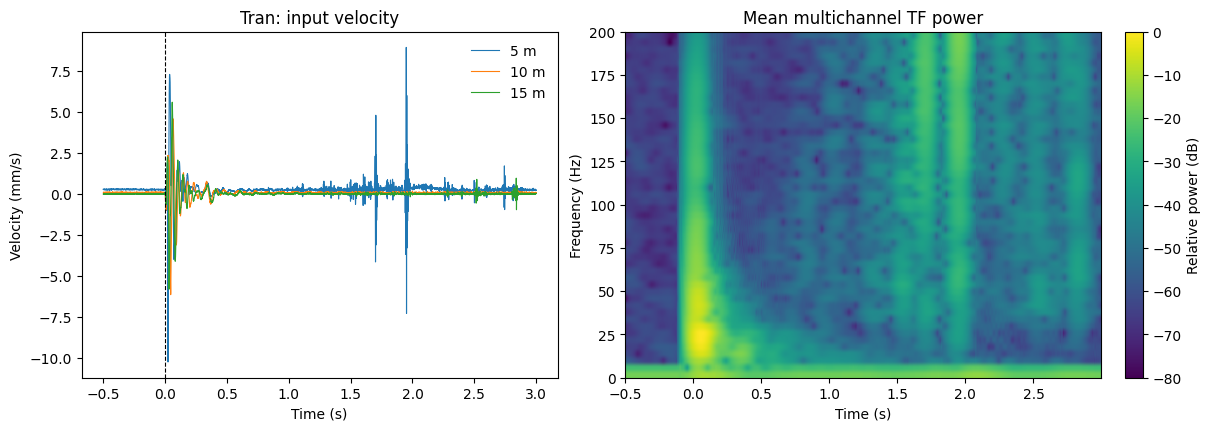

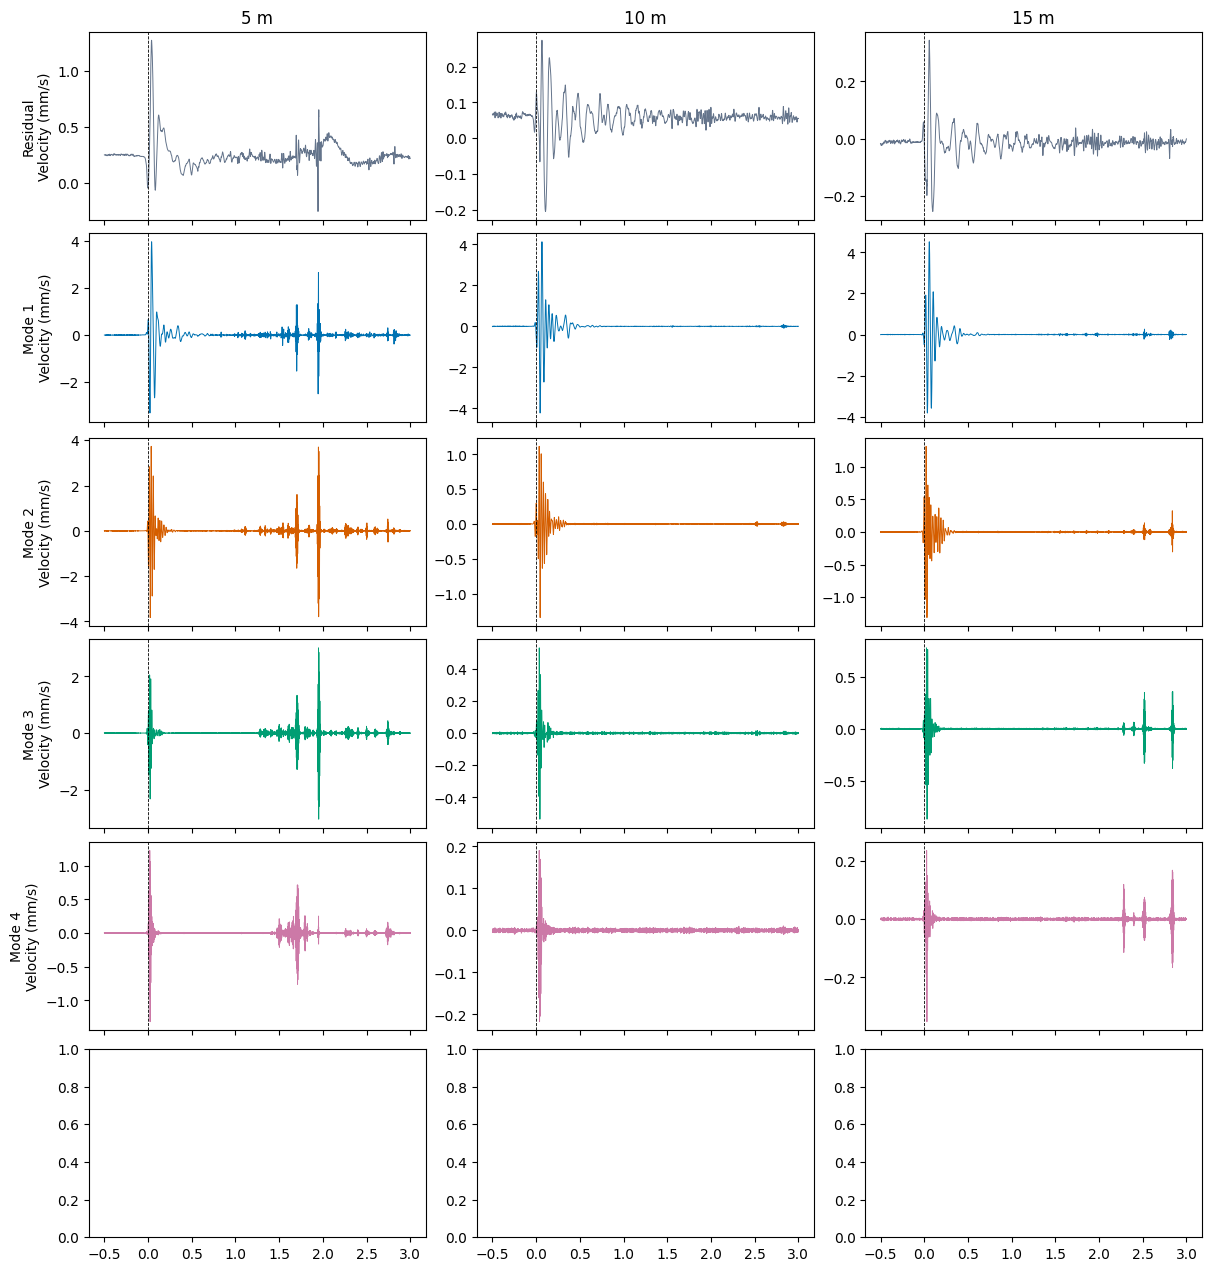

In [38]:
results = {}
figures_by_direction = {}
results["Tran"], figures_by_direction["Tran"] = analyze_direction(
    "Tran", signals["Tran"], time_s, fs
)

## 5. Vert 方向

In [ ]:
results["Vert"], figures_by_direction["Vert"] = analyze_direction(
    "Vert", signals["Vert"], time_s, fs
)

## 6. Long 方向

In [ ]:
results["Long"], figures_by_direction["Long"] = analyze_direction(
    "Long", signals["Long"], time_s, fs
)

## 7. 结果保存

In [ ]:
OUTPUT_DIR = Path("output/stvmd_blast")
CONFIG_SNAPSHOT = {
    "K": K, "ALPHA": ALPHA, "WINDOW_LENGTH": WINDOW_LENGTH,
    "TAU": TAU, "TOL": TOL, "MAX_ITERS": MAX_ITERS,
    "BATCH_WINDOWS": BATCH_WINDOWS, "PLOT_MAX_HZ": PLOT_MAX_HZ,
}
if SAVE_OUTPUTS:
    for direction, direction_figures in figures_by_direction.items():
        save_direction_figures(OUTPUT_DIR, direction, direction_figures)
    save_all_results(OUTPUT_DIR, results, CONFIG_SNAPSHOT)
    print(f"结果已保存到: {OUTPUT_DIR.resolve()}")
else:
    print("SAVE_OUTPUTS=False：未写出结果文件。")